<a href="https://colab.research.google.com/github/srujithach0-lang/Pandas_Analysis.ipynb/blob/main/trendpulse_srujitha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import requests
import json
import os
import time
from datetime import datetime

# --- constants & configuration ---
TOP_STORIES_URL = "https://hacker-news.firebaseio.com/v0/topstories.json"
ITEM_URL_TEMPLATE = "https://hacker-news.firebaseio.com/v0/item/{id}.json"
# mandatory Headers
headers = {"User-Agent": "TrendPulse/1.0"}
DATA_DIR = "data"
# Mapping categories to keywords for matching
CATEGORIES ={
    "technology": ["ai", "software", "tech", "code", "data", "cloud", "API", "GPU", "LLM"],
    "worldnews": ["war", "government", "country", "president", "election","climate", "attack", "global"],
    "sports": ["NFL", 'NBA', "FIFA", "sport", "game", "team", "player", "league", "championship", "hockey", "tennis", "golf"],
    "science":["research", "study", "space", "physics", "biology", "discovery", "NASA", "genome", "AI in science", "datascience", "environment"],
    "entertainment":["movies", "film", "music", "Netflix", "game", "book", "show", "award", "streaming", "celebrity", "tv", "anime"]

}
def task_1_fetch():
    # 1. Create data folder if it doesn't exist
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR)

    print("Fetching ID's...")
    ids = requests.get(TOP_STORIES_URL, headers = headers).json()[:500]
    all_stories = []

    for cat_name, keywords in CATEGORIES.items():
        #stop if already hit 25 stories for this category
        found = 0
        for s_id in ids:
            if found >= 25:
                break
            try:
                story = requests.get(ITEM_URL_TEMPLATE.format(id=s_id), headers = headers).json()
                title = story.get('title', '')
                # Case-insensitive check: if any keyword exist in the title
                if any(word.lower() in title.lower() for word in keywords):
                    # Extract the 7 reruried fields
                    all_stories.append({
                        "post_id": story.get("id"),
                        "title": title,
                        "category": cat_name,
                        "score": story.get("score", 0),
                        "num_comments": story.get("descendants", 0),
                        "author": story.get("by", "unknown"),
                        "collected_at": datetime.now().strftime("%y-%m-%d %H:%M:%S")

                    })

                    found += 1
            except: continue
        print(f"Finished {cat_name}...")
        # Requried: 2s delay between requests to avoid hitting API limits
        time.sleep(2)

    # save to json file
    filename = f"{DATA_DIR}/trends_{datetime.now().strftime('%Y%m%d')}.json()"
    with open(filename, 'w') as f:
        json.dump(all_stories, f, indent=4)
    print(f"collected {len(all_stories)} stories. Saved to {filename}")
    return filename

if __name__ == "__main__":
    json_file = task_1_fetch()

Fetching ID's...
Finished technology...
Finished worldnews...
Finished sports...
Finished science...
Finished entertainment...
collected 105 stories. Saved to data/trends_20260402.json()


In [17]:
import pandas as pd

def task_2_clean(json_input):
    print("cleaning data...")
    # Load the JSON into a DataFrame
    df = pd.read_json(json_input)

    # Fill missing values with defaults
    df['score'] = df['score'].fillna(0)
    df['num_comments'] = df['num_comments'].fillna(0)

    # Clean title by removing extra whitespaces
    df['title'] = df['title'].str.strip()

    # Save cleaned data to CSV
    output_csv = "data/trends_cleaned.csv"
    df.to_csv(output_csv, index=False)
    print(f"cleaned data saved to {output_csv}")
    return output_csv

if __name__ == "__main__":
    # Example input json file from task1
    import glob
    latest_json = max(glob.glob("data/trends_*.json()"))
    task_2_clean(latest_json)

cleaning data...
cleaned data saved to data/trends_cleaned.csv


In [18]:
import pandas as pd

def task_3_analyze(csv_input):
    df = pd.read_csv(csv_input)

    # 1. Top 5 or Group by category
    summary = df.groupby('category').agg({
        'score': 'mean',
        'num_comments': 'sum',
        'post_id': 'count'
    }).rename(columns={'post_id': 'story_count', 'score': 'avg_score'})

    print("\n--- category summary ---")
    print(summary)


    # Finding Top 5 "Viral" stories based on score and num_comments
    df['engagement'] = df['score'] + df['num_comments']
    top_viral = df.nlargest(5, 'engagement') [['title', 'category', 'score', 'engagement', 'author']]

    print("\n--- Top 5 viral stories ---")
    print(top_viral)
    return summary

if __name__ == "__main__":
    task_3_analyze("data/trends_cleaned.csv")


--- category summary ---
                avg_score  num_comments  story_count
category                                            
entertainment  101.640000          1390           25
science         77.086957           943           23
sports         131.333333           491            9
technology     106.800000          1616           25
worldnews      115.043478          1583           23

--- Top 5 viral stories ---
                                                 title       category  score  \
41                            Hold on to Your Hardware      worldnews    661   
16   OpenAI closes funding round at an $852B valuation     technology    520   
29   Fedware: Government apps that spy harder than ...      worldnews    678   
104  My MacBook keyboard is broken and it's insanel...  entertainment    381   
57                           SpaceX files to go public        science    326   

     engagement        author  
41         1194     LucidLynx  
16         1005  surprisetalk

Visualisation saved as data/trend_analysis.png


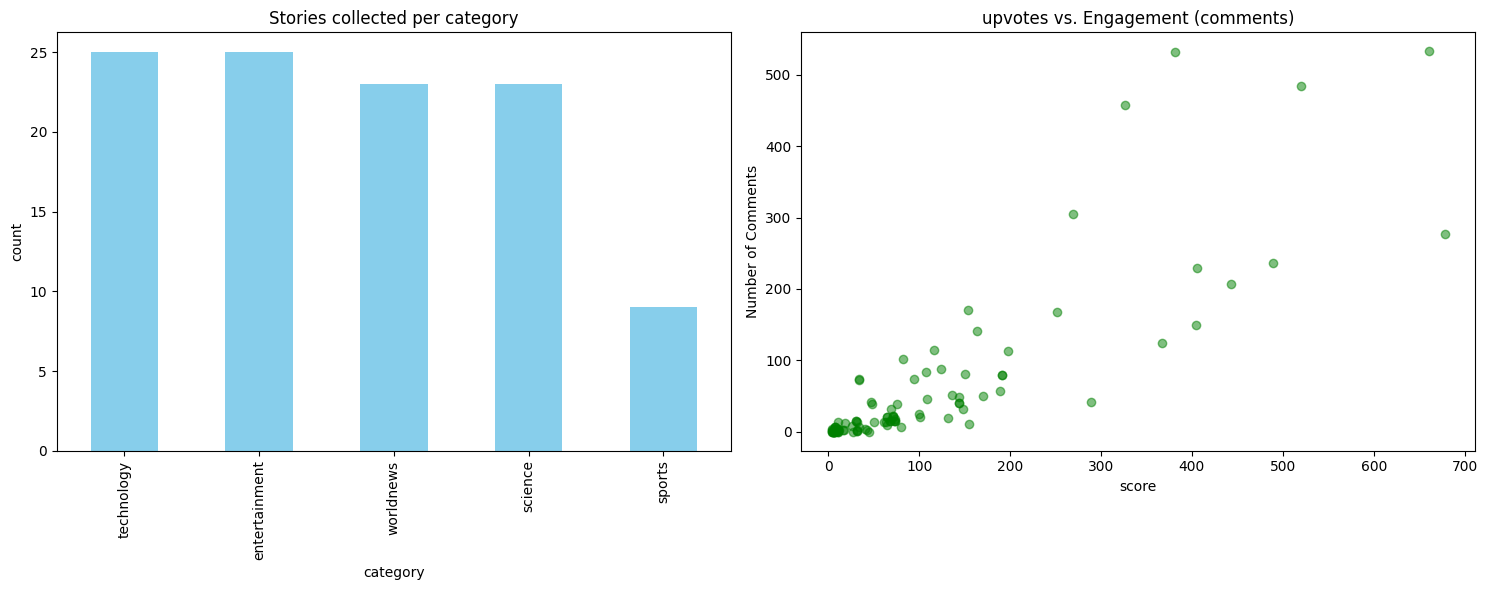

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

def task_4_visualize(csv_input):
    df = pd.read_csv(csv_input)

    # Create a figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1. stories count by category
    df['category'].value_counts().plot(kind='bar', ax=ax1, color='skyblue')
    ax1.set_title("Stories collected per category")
    ax1.set_ylabel("count")

    # plot 2. Score vs num_comments scatter plot
    ax2.scatter(df['score'], df['num_comments'], alpha=0.5, color='green')
    ax2.set_title("upvotes vs. Engagement (comments)")
    ax2.set_xlabel("score")
    ax2.set_ylabel("Number of Comments")

    plt.tight_layout()
    plt.savefig("data/trend_analysis.png")
    print("Visualisation saved as data/trend_analysis.png")
    plt.show()

if __name__ == "__main__":
    task_4_visualize("data/trends_cleaned.csv")